In [1]:
### Please check _common.py for common paths and loaded packages 
from _common import *

### Automatic reloading of modules
%load_ext autoreload
%autoreload 2

%matplotlib inline

## Read atmospheric data

In [131]:
### Hurricane track ###
# Hurricane information: 2012 Isaac
tc_info = tc_func.get_tc_info(year=2012, name='Isaac', agency='USA')

# Interpolation function for TC track
f_loc, t0 = tc_func.get_interp_func(tc_info)

### Seismic station ###
# Read seismic station list
sta_info = pd.read_csv(os.path.join(data_dir, 'TA/TA_list.csv'))

# Specific seismic station
seis_sta_loc = np.array([get_sta_loc(['TA', '645A'], sta_info)])[0]

### ASOS station ###
# Read ASOS station metadata
csv_files = [os.path.join(data_dir, 'ASOS/LA_meta.csv')]

start_date = pd.to_datetime('2012-08-01')
end_date = pd.to_datetime('2012-10-01')
asos_info = read_asos_metadata(csv_files, start_date, end_date)

# Specific ASOS station
asos_sta_loc = np.array([get_asos_sta_loc('ASD', asos_info)])[0]

### ERA5 reanalysis data ###
era5_dir = os.path.join(data_dir, 'Isaac/ERA5')
t1, t2 = '2012-08-27T00:00:00', '2012-09-01T00:00:00'

# Read ERA5 data: Single level
era5_file = os.path.join(era5_dir, 'data_stream-oper.nc')
era5_slev_data = atm_ds.read_era5(era5_file, ts=t1, te=t2)

# Read ERA5 data: Pressure levels
era5_file = os.path.join(era5_dir, 'data_pres_level.nc')
era5_plev_data = atm_ds.read_era5(era5_file, ts=t1, te=t2)

ERA5: Single level
ERA5: Pressure level


In [111]:
### NEXRAD VAD Profile ###
vad_data = xr.open_dataset(os.path.join(data_dir, 'Isaac/NEXRAD/KLIX_VAD.nc'))
nexrad_sta_loc = (vad_data.longitude, vad_data.latitude)

geod = Geod(ellps='WGS84')
_az, _, _dist = geod.inv(nexrad_sta_loc[0], nexrad_sta_loc[1], asos_sta_loc[0], asos_sta_loc[1])
print(f'Distance from NEXRAD (KLIX) to ASOS (ASD): {_dist/1e3:.2f} km, Azimuth: {_az:.2f} deg')

### ASOS station ###
asos_data, _ = tc_func.read_ASOS_data(os.path.join(data_dir, 'ASOS/546A_ASD.csv'))
asos_data = asos_data[(asos_data['wind'] > 0)]

### Average VAD profiles over time ###
z_vad = np.linspace(0, 3e3, 301)
wspd_vad = np.full((len(era5_slev_data.valid_time), len(z_vad)), np.nan)
for i, t1 in enumerate(era5_slev_data.valid_time.values):

    # Select VAD data within +/- 30 minutes of ERA5 time
    t1_ = pd.to_datetime(t1)
    vad_sel = vad_data.sel(time=slice(t1_-timedelta(minutes=30), t1_+timedelta(minutes=30)))

    if vad_sel.time.size == 0:
        continue

    # Time-average
    tmp = np.full((len(vad_sel.time), len(z_vad)), np.nan)
    for j in range(len(vad_sel.time)):
        tmp[j,:] = np.interp(z_vad, vad_sel['alt'].isel(time=j), np.sqrt(vad_sel['u'].isel(time=j)**2 + vad_sel['v'].isel(time=j)**2), 
                             left=np.nan, right=np.nan)
    wspd_vad[i, :] = np.mean(tmp, axis=0)

### Average ASOS wind over time ###
asos_data['time'] = pd.to_datetime(asos_data['time'])
wspd_asos = np.full(len(era5_slev_data.valid_time), np.nan)
for i, t1 in enumerate(era5_slev_data.valid_time.values):

    # Select ASOS data within +/- 30 minutes of ERA5 time
    t1_ = pd.to_datetime(t1)
    mask = (
        (asos_data['time'] >= t1_ - timedelta(minutes=30)) &
        (asos_data['time'] <= t1_ + timedelta(minutes=30))
    )
    if not mask.any():
        continue

    # Time-average surface wind
    wspd_asos[i] = asos_data.loc[mask, 'wind'].mean()


Distance from NEXRAD (KLIX) to ASOS (ASD): 0.75 km, Azimuth: 21.08 deg


In [158]:
### Average VAD profiles over time ###
alt_vad = vad_data["alt"].values
z_vad = np.unique(alt_vad[np.isfinite(alt_vad)])
wspd_vad = np.full((len(era5_slev_data.valid_time), len(z_vad)), np.nan)

for i, t1 in enumerate(era5_slev_data.valid_time.values):

    # Select VAD data within +/- 30 minutes of ERA5 time
    t1_ = pd.to_datetime(t1)
    vad_sel = vad_data.sel(time=slice(t1_-timedelta(minutes=30), t1_+timedelta(minutes=30)))
    if vad_sel.time.size == 0:
        continue
    wspd_sel = np.sqrt(vad_sel['u'].values**2 + vad_sel["v"].values**2)

    # Time-average
    for j, zj in enumerate(z_vad):
        mask = (vad_sel['alt'].values == zj) & np.isfinite(wspd_sel)
        if np.any(mask):
            wspd_vad[i,j] = np.nanmean(wspd_sel[mask])

## Wind analysis

Minimum distance from ASD to hurricane center: 118.04 km


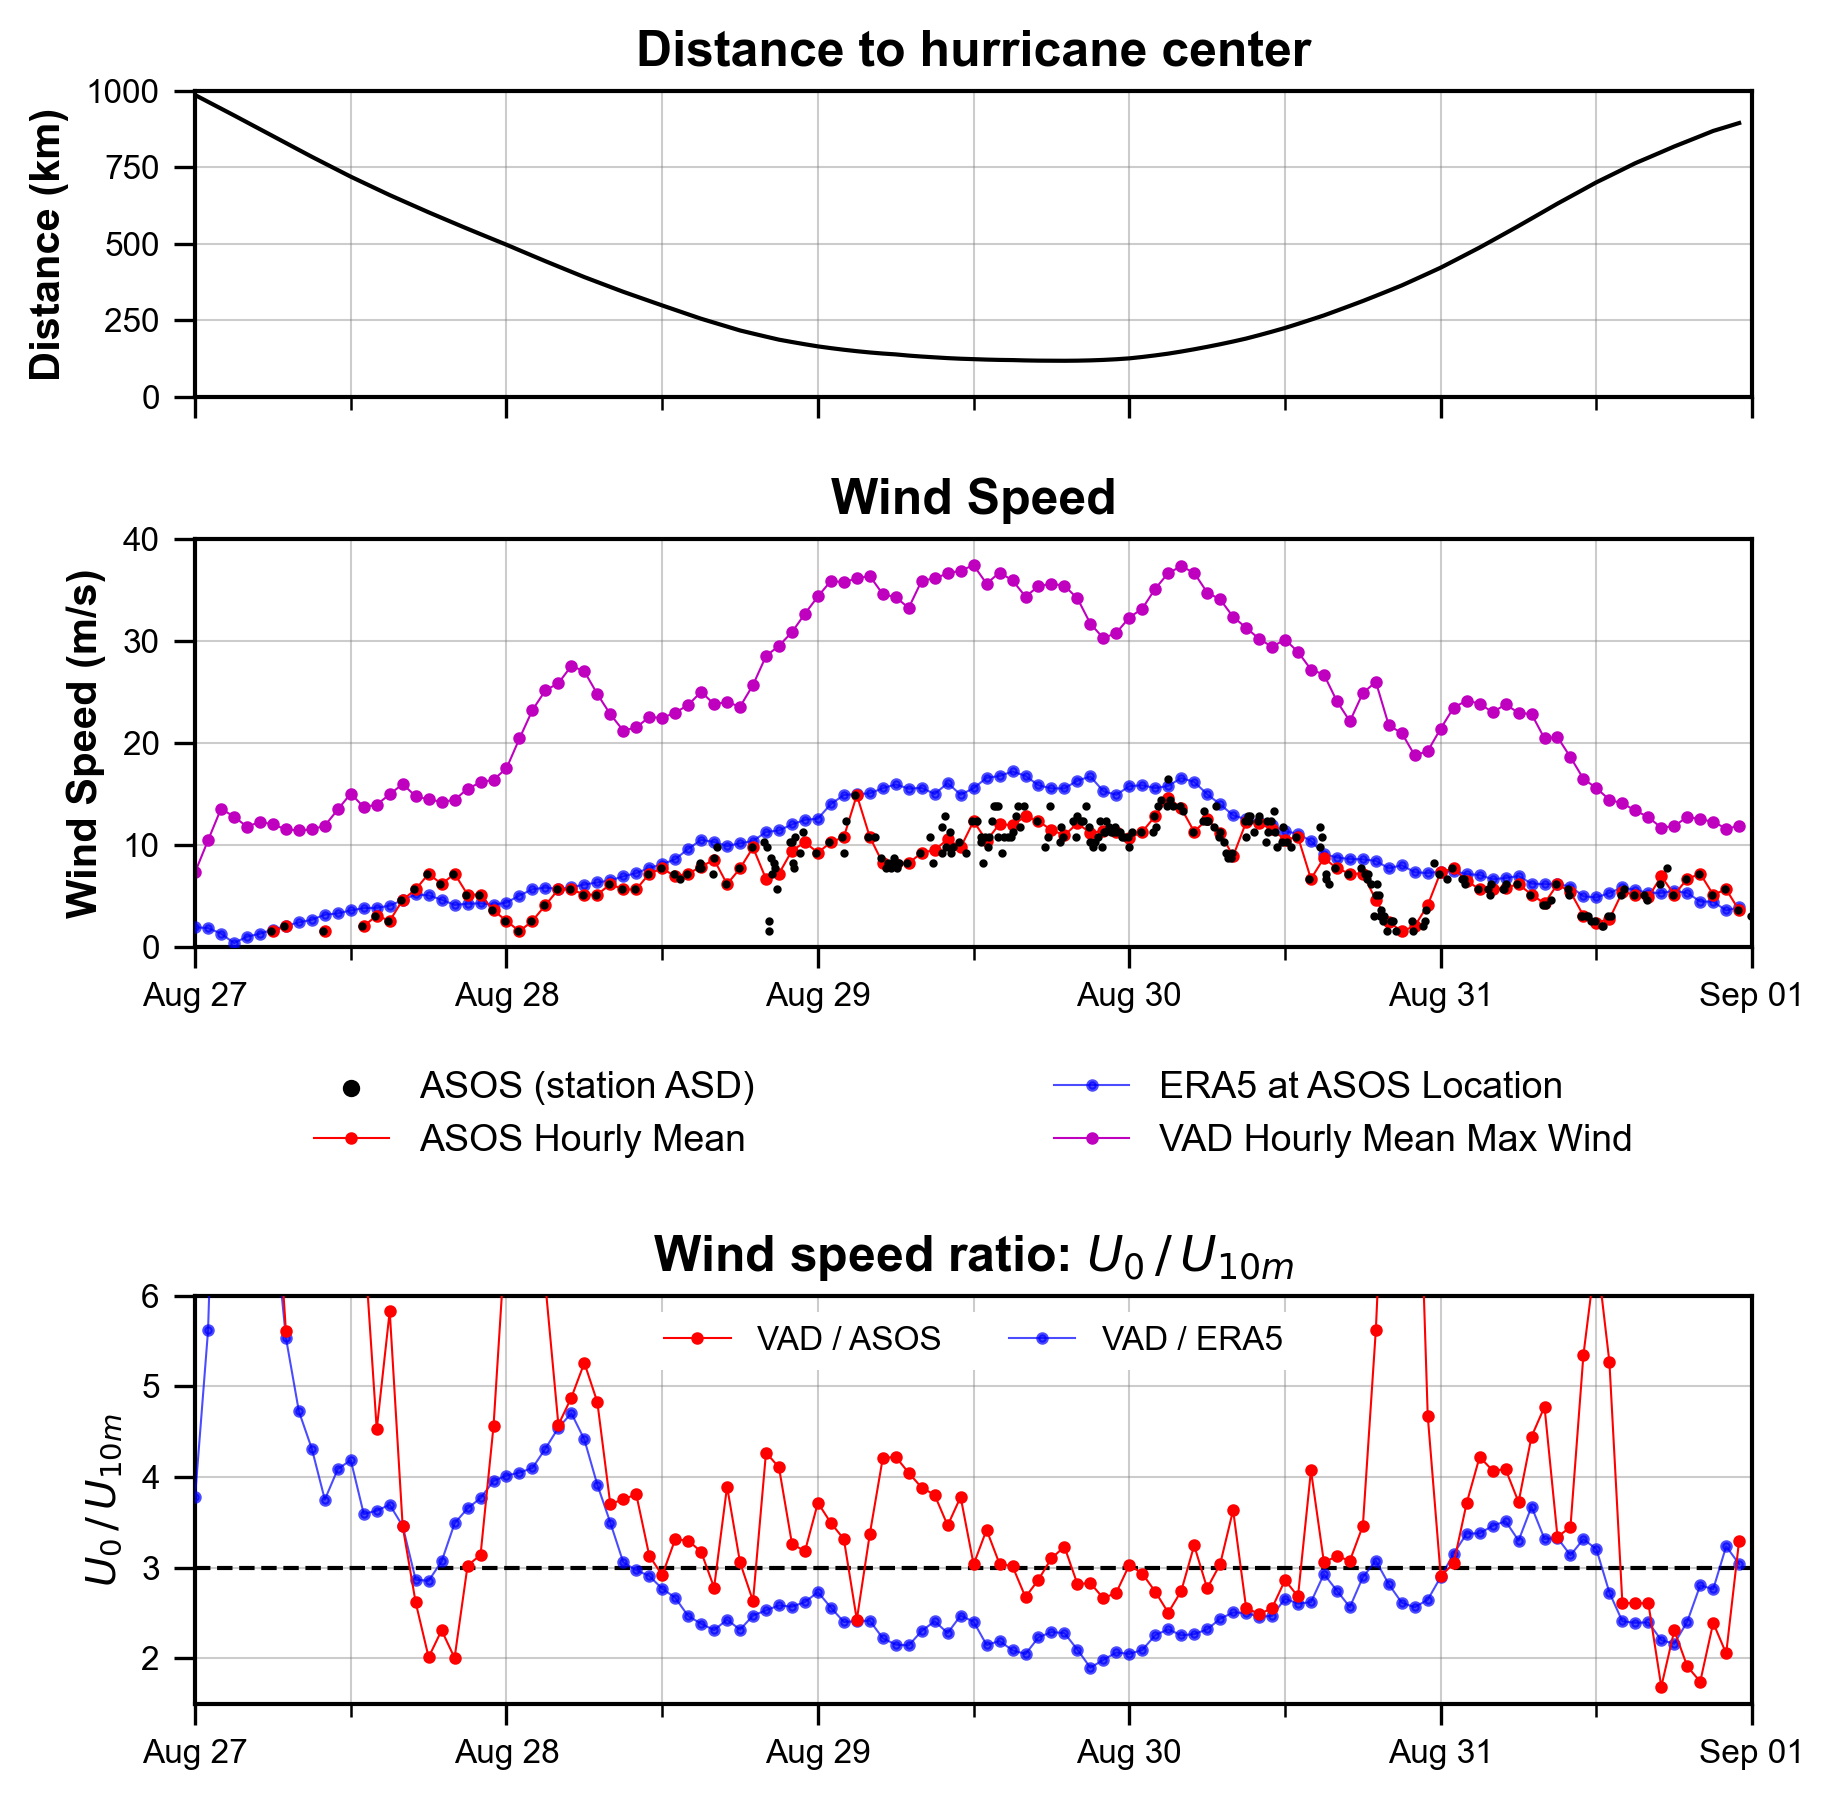

In [242]:
### Plotting time range ###
tplot1, tplot2 = UTCDateTime(2012, 8, 27), UTCDateTime(2012, 9, 1)

### Station distance to TC ###
tc_timestamp, tc_lon, tc_lat = tc_func.interp_track(f_loc, t0, time_range=[tplot1, tplot2])
tc_dist = tc_func.get_station_dist(asos_sta_loc, np.array([tc_lon, tc_lat]))
print(f'Minimum distance from ASD to hurricane center: {np.nanmin(tc_dist):.2f} km')

### ERA5 at ASOS station ###
era5_slev_asos = era5_slev_data.interp(latitude=asos_sta_loc[1], longitude=asos_sta_loc[0])
era5_slev_asos['wspd'] = np.sqrt(era5_slev_asos['u10']**2 + era5_slev_asos['v10']**2)

### Max VAD wind ###
z_mask = (z_vad <= 2000.0)
wspd_sub = wspd_vad[:, z_mask]
z_sub = z_vad[z_mask]
wspd_vad_max = np.nanmax(wspd_sub, axis=1)
z_vadmax = z_vad[np.nanargmax(wspd_sub, axis=1)]

### Plotting ###
fig, axes = plt.subplots(3, 1, figsize=(6, 6), sharex=True, constrained_layout=True,
                         gridspec_kw={'height_ratios': [1.5, 2, 2]})
fig.set_constrained_layout_pads(h_pad=0.1)

# TC distance plot
axes[0].plot(tc_timestamp, tc_dist, 'k-', lw=1)
axes[0].set_ylabel('Distance (km)')
axes[0].set_ylim([0, 1000])
axes[0].set_title('Distance to hurricane center')

# Wind speed plot
axes[1].scatter(asos_data['time'], asos_data['wind'], s=1, marker='o', color='k', label='ASOS (station ASD)', zorder=15)
axes[1].plot(era5_slev_data['valid_time'], wspd_asos, 'r.-', lw=0.5, label='ASOS Hourly Mean', zorder=11)
axes[1].plot(era5_slev_asos['valid_time'], era5_slev_asos['wspd'].values, 'b.-', lw=0.5, label='ERA5 at ASOS Location', zorder=9, alpha=0.7)
axes[1].plot(era5_slev_data['valid_time'], wspd_vad_max, 'm.-', lw=0.5, label='VAD Hourly Mean Max Wind')
axes[1].set_xlim([tplot1, tplot2])
axes[1].xaxis.set_minor_locator(mdates.HourLocator(byhour=12))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[1].set_ylabel('Wind Speed (m/s)')
axes[1].set_ylim([0, 40])
axes[1].set_title('Wind Speed')
axes[1].tick_params(axis='x', labelbottom=True)

handles, labels = axes[1].get_legend_handles_labels()
legend = axes[1].legend(handles, labels, loc='lower center', 
                    ncol=2, prop={'size': 9}, frameon=False,
                    bbox_to_anchor=(0, -0.6, 1, 0.5), columnspacing=8.0)
for handle in legend.legend_handles:
    handle._sizes = [10]

# Wind speed ratio plot
axes[2].plot(era5_slev_data['valid_time'], wspd_vad_max / wspd_asos, 'r.-', lw=0.5, label='VAD / ASOS', zorder=10)
axes[2].plot(era5_slev_asos['valid_time'], wspd_vad_max / era5_slev_asos['wspd'].values, 'b.-', lw=0.5, label='VAD / ERA5', zorder=9, alpha=0.7)
axes[2].axhline(3.0, color='k', lw=1, ls='--', zorder=5)
axes[2].set_ylabel(r'$U_0\, / \,U_{10m}$')
axes[2].set_ylim([1.5, 6])
axes[2].set_title(r'Wind speed ratio: $U_0\, / \,U_{10m}$')
axes[2].legend(fontsize=8, ncol=2, frameon=True, edgecolor='None')

for ax in axes.flat:
    ax.grid(which='both', linestyle='-', alpha=0.4)

# fig.savefig(os.path.join(sup_dir, 'wind_ASD.pdf'), dpi=400, bbox_inches='tight', pad_inches=0)

## Height scales

In [251]:
### Height of U(z) = 0.6*U0 ###

wspd_Uc = 0.6 * wspd_vad_max
zc = np.full(wspd_vad.shape[0], np.nan)

for t in range(wspd_vad.shape[0]):

    w = wspd_sub[t, :]
    i_peak = np.nanargmax(w)

    # Restrict to below-max (ascending) branch
    w_up, z_up = w[:i_peak+1], z_sub[:i_peak+1]
    good = np.isfinite(w_up)
    w_up, z_up = w_up[good], z_up[good]
    if w_up.size < 2:
        continue

    # Find first crossing where U >= Uc
    above = (w_up >= wspd_Uc[t])
    if not np.any(above):
        continue
    k = np.argmax(above)
    if k == 0:
        zc[t] = z_up[0]
        continue

    # linear interpolation between bracketing points
    z1, z2 = z_up[k-1], z_up[k]
    w1, w2 = w_up[k-1], w_up[k]

    if w2 == w1:
        zc[t] = z1
    else:
        zc[t] = z1 + (wspd_Uc[t] - w1) * (z2 - z1) / (w2 - w1)


Minimum distance from 645A to hurricane center: 4.21 km


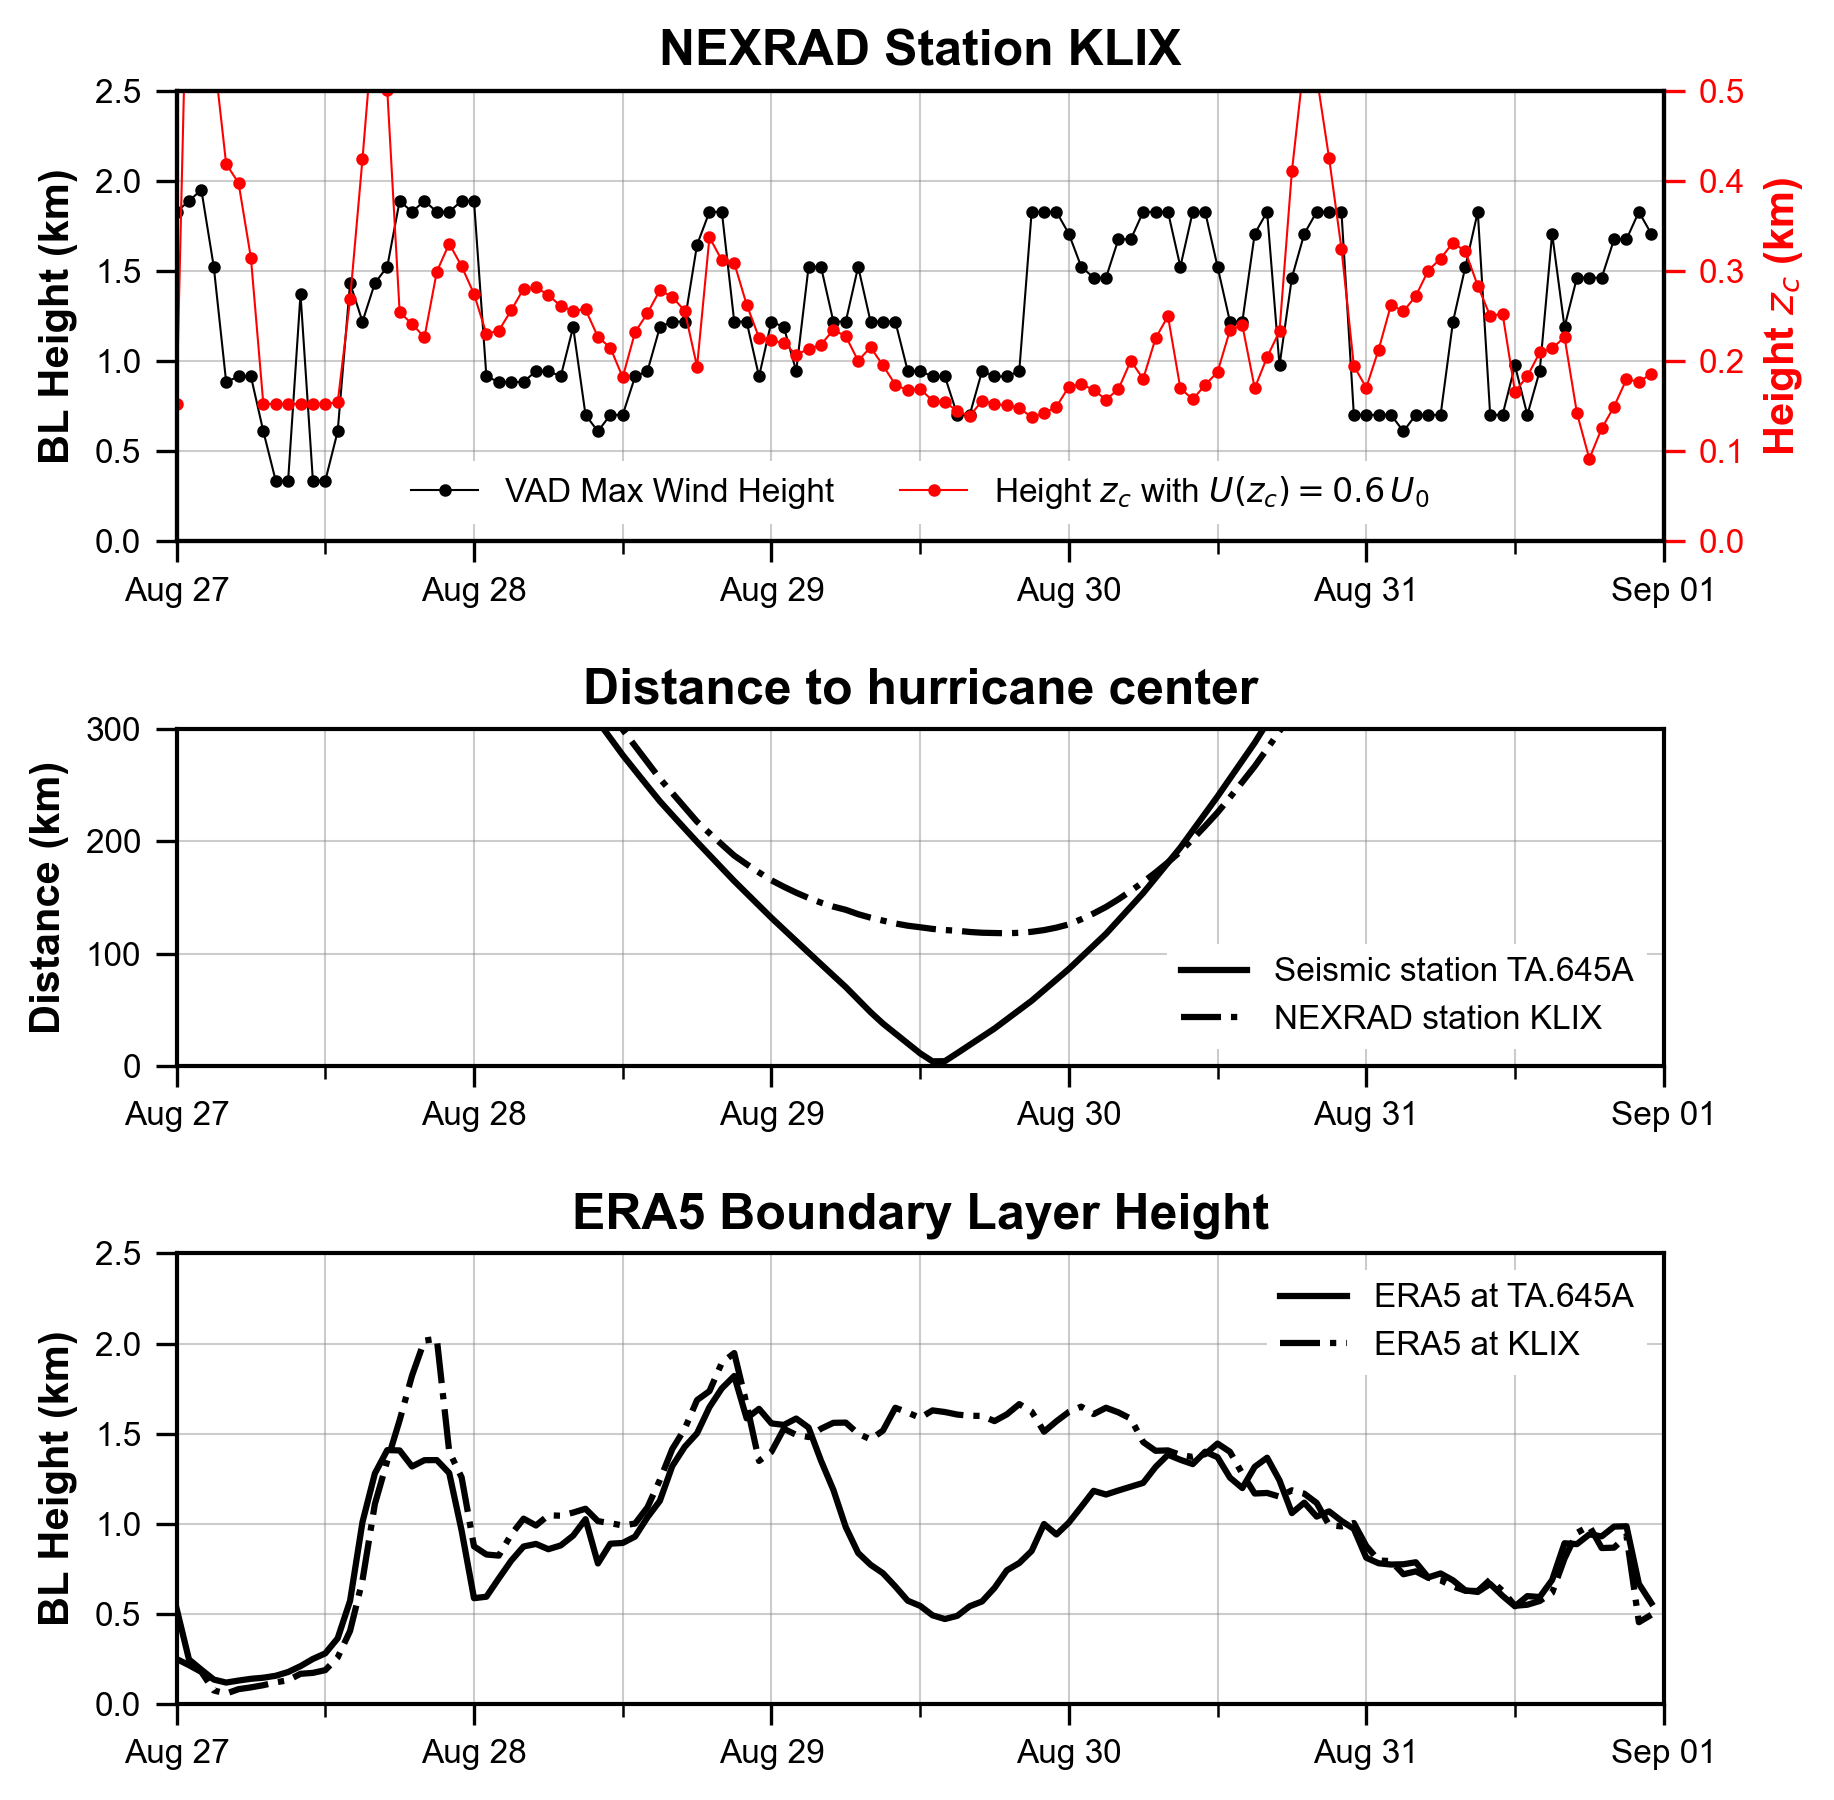

In [266]:
### ERA5 at seismic station ###
era5_slev_seis = era5_slev_data.interp(latitude=seis_sta_loc[1], longitude=seis_sta_loc[0])
era5_slev_seis['wspd'] = np.sqrt(era5_slev_seis['u10']**2 + era5_slev_seis['v10']**2)

### Station distance to TC ###
tc_dist2 = tc_func.get_station_dist(seis_sta_loc, np.array([tc_lon, tc_lat]))
print(f'Minimum distance from 645A to hurricane center: {np.nanmin(tc_dist2):.2f} km')

# Plot boundary layer height
fig, axes = plt.subplots(3, 1, figsize=(6, 6), sharex=True, constrained_layout=True,
                         gridspec_kw={'height_ratios': [2, 1.5, 2]})
fig.set_constrained_layout_pads(h_pad=0.1)
obj1, = axes[0].plot(era5_slev_data['valid_time'], z_vadmax/1e3, 'k.-', lw=0.5)
axes[0].tick_params(axis='x', labelbottom=True)
axes[0].set_ylabel('BL Height (km)')
axes[0].set_ylim([0, 2.5])
axes[0].set_title('NEXRAD Station KLIX')

ax_ = axes[0].twinx()
obj2, = ax_.plot(era5_slev_data['valid_time'], zc/1e3, 'r.-', lw=0.5)
ax_.set_ylim([0, 0.5])
ax_.set_ylabel(r'Height $z_c$ (km)', color='r')
ax_.tick_params(axis='y', colors='r')
axes[0].legend(handles=[obj1, obj2], labels=['VAD Max Wind Height', r'Height $z_c$ with $U(z_c)=0.6\,U_0$'], 
               ncol=2, fontsize=8, edgecolor='None', loc='lower center')

axes[1].plot(tc_timestamp, tc_dist2, 'k-', lw=1.5)
axes[1].plot(tc_timestamp, tc_dist, 'k-.', lw=1.5)
axes[1].tick_params(axis='x', labelbottom=True)
axes[1].set_ylabel('Distance (km)')
axes[1].set_ylim([0, 300])
axes[1].set_title('Distance to hurricane center')
axes[1].legend(labels=['Seismic station TA.645A', 'NEXRAD station KLIX'], 
               fontsize=8, loc='lower right', edgecolor='None')

axes[2].plot(era5_slev_seis['valid_time'], era5_slev_seis['blh'].values/1e3, 'k-', lw=1.5)
axes[2].plot(era5_slev_asos['valid_time'], era5_slev_asos['blh'].values/1e3, 'k-.', lw=1.5)
axes[2].set_ylabel('BL Height (km)')
axes[2].set_title('ERA5 Boundary Layer Height')
axes[2].set_ylim([0, 2.5])
axes[2].set_xlim([tplot1, tplot2])
axes[2].xaxis.set_minor_locator(mdates.HourLocator(byhour=12))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

axes[2].legend(labels=['ERA5 at TA.645A', 'ERA5 at KLIX'], 
               fontsize=8, loc='upper right', edgecolor='None')

for ax in axes.flat:
    ax.grid(which='both', linestyle='-', alpha=0.4)

# fig.savefig(os.path.join(sup_dir, 'height_BL.pdf'), dpi=400, bbox_inches='tight', pad_inches=0)

In [ ]:
### ERA5 Reanalysis: Interpolation ###
era5_slev_nexrad = era5_slev_data.interp(latitude=nexrad_sta_loc[1], longitude=nexrad_sta_loc[0])
era5_plev_nexrad = era5_plev_data.interp(latitude=nexrad_sta_loc[1], longitude=nexrad_sta_loc[0])